# DEF-D Fysieke Ontwerpopdracht 5 Invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 39     |  |
| :-------------|:-------------|
| Nynke Bouwhuis | 6508049 |
| Tim Mekkelholt| 6224687 |
| Ben Geertman | 6529100 |

## Opdracht 1: Planning.

| Planning Groep: 39     |Tijdstip / Tijdspanne  | door wie  |
|---|---|---|
| Arduino testen| Tijdspanne | Ben |
| ontwerp-eis berekenen| Tijdspanne | Nynke & Tim |
| sanity check (Arduino/ontwerp-eis) | 10.45 - 12.30 | hele groep |
| bouwen en meten | 13.30 - 16.00 | hele groep |
| sanity checks | 12.30 | ---|
| alles gemeten | 16.00 | ---|
| Pauze 1| 12.30 - 13.30 | hele groep |
| Pauze 2| 14.45 - 15.00 | hele groep |

Run onderstaande cel om alle benodigde libraries te laden. Mogelijk voeg je er zelf nog een aantal toe later vandaag. 

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
import math

## Opdracht 2a: Opsplitsen taak 1: Arduino
Vul onderstaande tabel in:

| onderwerp    | antwoord  |
|---|---|
| hoe moeilijk (schaal 1 - 10) | 4 |
| hoe lang voor één meting | 20 sec |
| verwacht nauwkeurigheid meting | 0.2 m/s**2 |

## Opdracht 2b: Opsplitsen taak 2: afleiding ontwerpeis

In [2]:
# Bereken hier je benodigde kantelfrequentie

# 1 / (1 - (w**2 / w_0**2)) < - 1/3
# 1 - (w**2 / w_0**2) < - 3
# (w**2 / w_0**2) < 4
# w**2 < 4 w_0**2
# -2 w_0 < w < 2 w_0
# w_0 > w / 2 of w_0 < - w / 2
# 2 * pi * f > (2 * pi * f0)/2 met f0 = 5 Hz, geeft:
# f > 5/2 Hz

De berekende kantelfrequentie is 2.50 Hz.


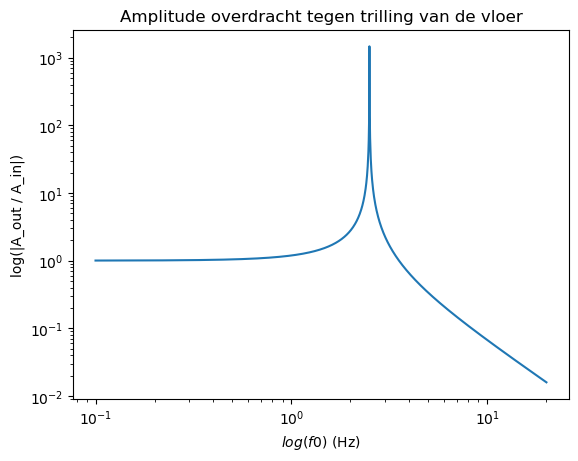

In [3]:
# Voeg hier je plot in.

f0 = 5 # vloerfrequentie in Hz
f = 5/2 # kantelfrequentie in Hz

f_0_array = np.linspace(0.1,20,2000) # variërende vloerfrequentie in Hz
w_array = 2*np.pi*f_0_array

w_0 = 2*np.pi*f
print(f'De berekende kantelfrequentie is {f:.2f} Hz.')

Amplitudeoverdracht = np.abs(1 / (1 - (w_array**2 / w_0**2)))

plt.figure()
plt.title('Amplitude overdracht tegen trilling van de vloer')
plt.plot(f_0_array, Amplitudeoverdracht, label= 'Data')
plt.xlabel('$log(f0)$ (Hz)')
plt.ylabel('log(|A_out / A_in|)')
plt.xscale('log')
plt.yscale('log')
plt.show()

In [4]:
# Bereken hier de minimale Delta-x waarbij je aan de eis van de opdracht voldoet.

g = 9.81
delta_x = g/w_0**2
print(f'De berekende delta x is {delta_x:.2f} m.')

De berekende delta x is 0.04 m.


## Opdracht 3: Plot de grafiek.

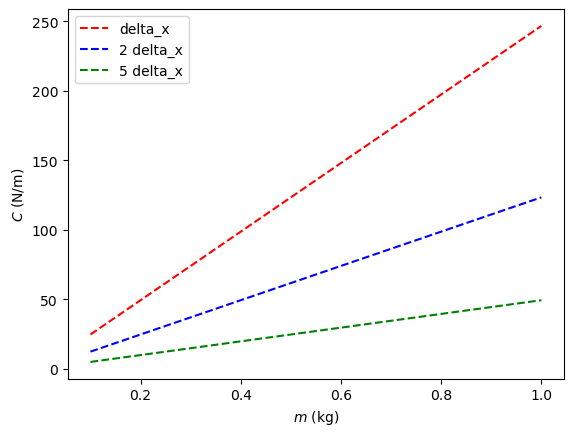

In [5]:
# Voeg hier je plot in. Lees goed de opdracht wat er in de grafiek moet staan!
# Het is ook handig om je grafiek op te slaan, doe dat door met plt.savefig().

m = np.linspace(0.1, 1, 100) # kg
C1 = m * g / delta_x
C2 = m * g / (2*delta_x)
C3 = m * g / (5*delta_x)

plt.figure()
plt.plot(m, C1, 'r--', label='delta_x')
plt.plot(m, C2, 'b--', label='2 delta_x')
plt.plot(m, C3, 'g--', label='5 delta_x')
plt.xlabel('$m$ (kg)')
plt.ylabel('$C$ (N/m)')
plt.legend()
plt.savefig('delta_x grafiek',dpi=450)
plt.show()

## Opdracht 4: Verander $\Delta x$.

We kunnen $\Delta x$ verhogen door:

- veerconstante lager
- massa hoger

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

Als groep gaan we mikken op een $\Delta x$ van: 
5cm, dit is net wat meer dan de geschatte minimale waarde van 2cm. Hierdoor nemen we eventuele onzekerheden mee.

## Opdracht 5: Schets.

##### schets opstelling: 
<img src="Ontwerpschets.png" width="400">

## Opdracht 6: Beslissing evaluatie

Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?

10 cm

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

Ja

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

Nog een extra 20 cm.

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

Ja

### Gaat je ontwerp dus voldoen aan de eis?

Ja

Als je hier positief geantwoord heb, maak dan nog een keer een plot van amplitude overdracht (y-as) versus frequentie (x-as) zoals je hierboven ook al een keer gedaan heb, maar plot nu twee verschillende overdrachten in de grafiek: één die je al had: behorende bij de grens van de ontwerp-eis en één behorende bij je eigen ontwerp. Lees af dat je voor je ontwerp daadwerkelijk onder de eis grafiek zit op de kritieke frequentie!

Deze grafiek heb je later weer nodig om je gemeten punten aan toe te voegen. Ga daarna je massa-veer systeem daadwerkelijk bouwen.

Als je hier negatief geantwoord hebt, kopieer onder deze cel dan alle cellen van Synthese tot en met Evaluation & decision en doorloop dat deel van het ontwerp proces nogmaals.

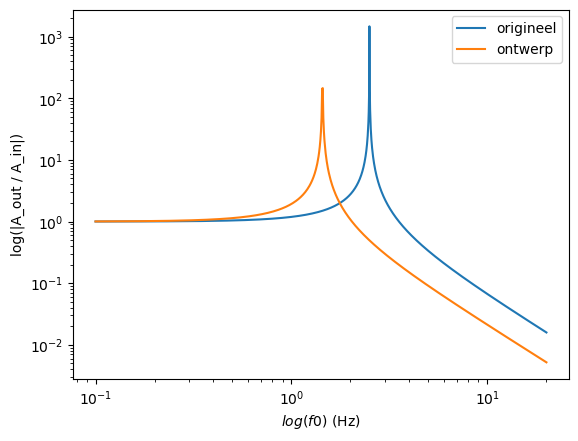

In [6]:
# Het eerste ontwerp werkte niet, vandaar hebben wij een nieuwe iteratie(s) gedaan en de berekeningen opnieuw uitgevoerd.

# Voeg hier je plot in.
delta_x_ontwerp = 12e-2 # m
w0_ontwerp = np.sqrt(g/delta_x_ontwerp)
Amplitudeoverdracht_ontwerp = np.abs(1/(1-(w_array**2/w0_ontwerp**2)))

plt.figure()
plt.plot(f_0_array, Amplitudeoverdracht, label= 'origineel')
plt.plot(f_0_array, Amplitudeoverdracht_ontwerp, label= 'ontwerp')
plt.xlabel('$log(f0)$ (Hz)')
plt.ylabel('log(|A_out / A_in|)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

## Opdracht 7: Plotten maar

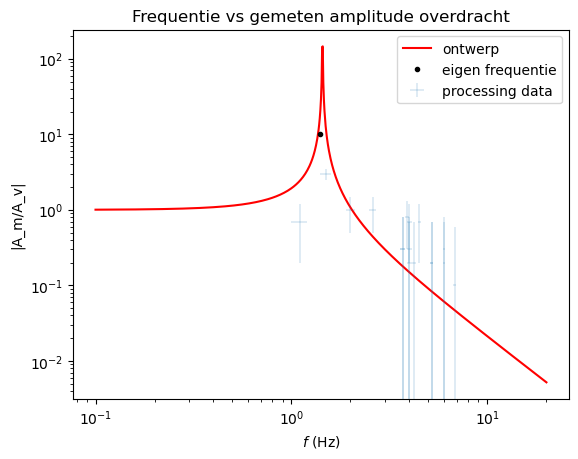

In [7]:
# Voeg hier je plots in.

# code toegevoegd waardoor processing de amplitude overdracht direct geeft (ook de amplituden en frequentie) om de aflees onzekerheid te verkleinen:

frequentie = np.array([5.2, 6, 5.2, 4.5, 3.9, 4, 4, 4, 4.2, 3.7, 3.7, 6.8, 6, 2.6, 2, 1.5, 1.1])
Amplitude_overdracht = np.array([0.2, 0.3, 0.2, 0.7, 0.8, 0.7, 0.3, 0.2, 0.2, 0.3, 0.3, 0.1, 0.2, 1, 1, 3, 0.7])

u_f = 0.1
u_A = 0.5

plt.figure()
plt.title('Frequentie vs gemeten amplitude overdracht')
plt.plot(f_0_array, Amplitudeoverdracht_ontwerp, 'r' , label= 'ontwerp')

plt.errorbar(frequentie, Amplitude_overdracht, xerr=u_f, yerr=u_A, label='processing data', ls='none', elinewidth=0.2)
plt.plot(1.4, 10, 'k.', label='eigen frequentie')
plt.xlabel('$f$ (Hz)')
plt.ylabel('|A_m/A_v|')

plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show('resultatengrafiek')

# Voor de freqentie 1.4 Hz resonantie (eigen frequentie)

-------------------------------------------------------------------------------------------------------------------------------------------------

## Opdracht 8: Leerdoelen 

## Leerdoel 1 - Inzien dat de parameters in een differentiaalvergelijking ontwerpparameters zijn die een ontwerpruimte opspannen:

### De ontwerpparameter dx:

In [8]:
# Bereken hier de minimale Delta-x waarbij je aan de eis van de opdracht voldoet.

# F_veer = kx en F_massa = mg
# mg = kdx -> dx = mg/k = g/w0^2

g = 9.81
delta_x = g/w_0**2
print(f'De berekende delta x is {delta_x:.2f} m.')

De berekende delta x is 0.04 m.


<img src="delta_x grafiek.png" width="400">


We kunnen $\Delta x$ verhogen door:

- veerconstante lager (een zwakkere veer gebruiken)
- massa hoger

-------------------------------------------------------------------------------------------------------------------------------------------------

## Leerdoel 2 - Op basis van een differentiaal vergelijking een keuze maken voor parameters en die vervolgens kunnen vertalen in een fysiek ontwerp:

## Opdracht 6: Beslissing evaluatie

Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?

10 cm

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

Ja

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

Nog een extra 20 cm.

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

Ja

### Gaat je ontwerp dus voldoen aan de eis?

Ja

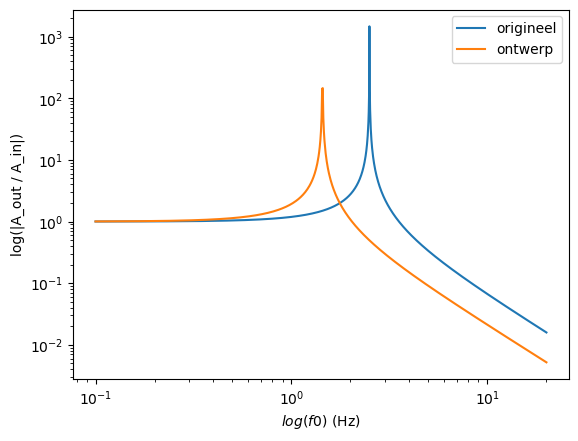

In [9]:
# Het eerste ontwerp werkte niet, vandaar hebben wij een nieuwe iteratie(s) gedaan en de berekeningen opnieuw uitgevoerd.

# Voeg hier je plot in.
delta_x_ontwerp = 12e-2 # m
w0_ontwerp = np.sqrt(g/delta_x_ontwerp)
Amplitudeoverdracht_ontwerp = np.abs(1/(1-(w_array**2/w0_ontwerp**2)))

plt.figure()
plt.plot(f_0_array, Amplitudeoverdracht, label= 'origineel')
plt.plot(f_0_array, Amplitudeoverdracht_ontwerp, label= 'ontwerp')
plt.xlabel('$log(f0)$ (Hz)')
plt.ylabel('log(|A_out / A_in|)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

#### Hieronder het fysieke ontwerp en de ontwerpgrafiek, gebaseerd op ontwerpkeuzes, met uiteindelijke meet-/datapunten die zijn verkregen met het fysieke ontwerp:

<img src="resultatengrafiek.png" width="500">
<img src="foto_opstelling.png" width="300">